EJERCICIO1_DESCRIPTIVO

OUTPUTS:

* ej1_descriptivo.csv: Tabla de estadísticos descriptivos de todas las variables numéricas
(pandas describe)

* ej1_histogramas.png: Histogramas

* ej1_boxplots.png: Boxplots de la variable objetivo por cada variable categórica

* ej1_heatmap_correlacion.png: Mapa de calor de la matriz de correlaciones

* ej1_categoricas.png: Gráficos de frecuencia de las variables categóricas


In [73]:
import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = pd.read_csv("data\\anthropometric_clean.csv")
df.head(3)

,gender,age,weight,height,shoulder_height,arms_reach,leg_length
0,M,18.0,65.0,173.5,144.0,173.0,102.0
1,M,18.0,73.0,170.0,152.0,176.0,106.0
2,M,18.0,82.0,192.0,167.0,193.0,115.0


In [74]:
# ------------------------------------------------------------------------------------------------------
# REGRESIÓN LINEAL
# ------------------------------------------------------------------------------------------------------

# Entrena el modelo con los datos de entrenamiento.
# Evalúa sobre el test set calculando: MAE, RMSE y R².
# Genera el gráfico de residuos (valores predichos en X, residuos en Y).
# Comenta los resultados en Respuestas.md: ¿el modelo es bueno?, ¿hay overfitting o underfitting?, ¿qué variables son más influyentes?


# Entrenamiento del modelo y predicción
 
df['gender'] = df['gender'].str.strip("'").map({'M': 0, 'F': 1})

y = df['height']
X = df[['gender', 'age', 'weight', 'arms_reach']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)

def entrenar_modelo(X: pd.DataFrame, y: pd.Series):

    reg = LinearRegression().fit(X, y)

    reg_results = {
        'R2': reg.score(X, y),
        'Intercept': reg.intercept_,
        'Weights': reg.coef_
    }

    return reg, reg_results 

def predecir_valores(reg: LinearRegression, X: pd.DataFrame):

    pred =  reg.predict(X)

    e = y_test - pred_y

    return pred, e


reg, reg_results = entrenar_modelo(X_train, y_train)
pred_y, e = predecir_valores(reg, X_test)


In [75]:
# Parámetros
print('Variables: ', ['gender', 'age', 'weight', 'arms_reach'])
print('Intercepto: ', reg_results['Intercept'])
print('Coeficientes: ', reg_results['Weights'])
print('R2: ', reg_results['R2'])    # muy buen ajuste (> 0.7)

Variables:  ['gender', 'age', 'weight', 'arms_reach']
Intercepto:  92.12528912206946
Coeficientes:  [-4.29405965 -0.11173452  0.14515518  0.44459115]
R2:  0.7786593694864127


In [76]:
# Errores 

reg_results['MAE'] = mean_absolute_error(y_test, pred_y)
reg_results['MSE'] = mean_squared_error(y_test, pred_y)

print('MAE: ', reg_results['MAE']) # el modelo se equivoca de media 3.32 cm (poco)
print('MSE: ', reg_results['MSE'])

def escribir_txt(reg_info: dict):
    
    with open("output\\ej2_metricas_regresion.txt", "w", encoding="utf-8") as archivo:
        archivo.write("PARÁMETROS Y ERRORES RESULTANTES DE LA REGRESIÓN:\n\n")
        for k, v in reg_info.items():
            archivo.write(f"{k}: {v}\n")

escribir_txt(reg_results)
            

MAE:  3.3229808203190094
MSE:  18.726085892076114


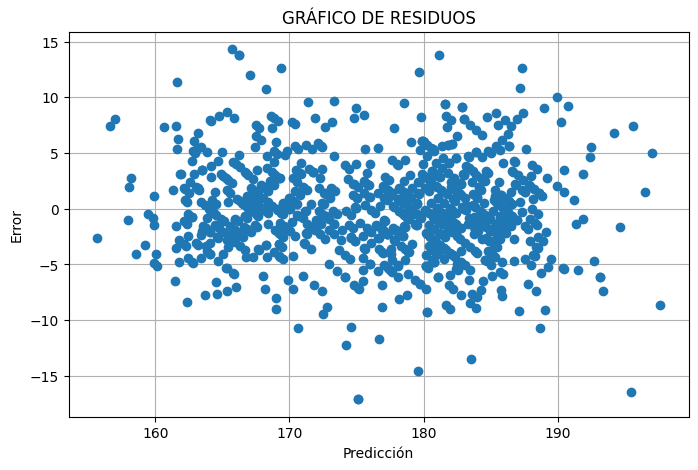

In [77]:
# Gráfica de residuos

def plot_residuos(pred_y: list, e: list):
    plt.figure(figsize = (8, 5))
    plt.scatter(pred_y, e, zorder = 3)
    plt.xlabel('Predicción')
    plt.ylabel('Error')
    plt.title('GRÁFICO DE RESIDUOS')
    plt.grid()
    plt.savefig("output\\ej2_residuos.png")
    plt.show()

plot_residuos(pred_y, e)

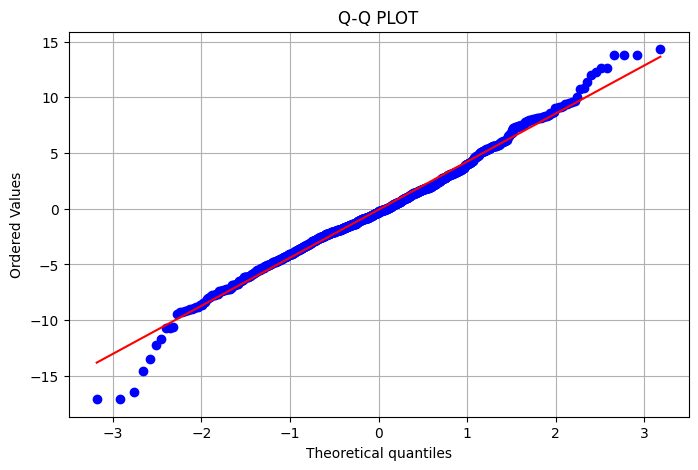

In [78]:
# QQ plot

plt.figure(figsize=(8,5))
stats.probplot(e, dist = 'norm', plot = plt)
plt.title('Q-Q PLOT')
plt.grid()
plt.show()
